### IBL Prior and Stim coding in Stimulus Interval


- Regions 
    - animal 1
    - animal 2
    - ...
    - animal n
- Load data
  - collate all the arrays into one (all pairs, etc)
  - different conditions
  - these are corrected measures
  - should I compute the same for biased (yes, think so)
- Plot data
  - Violin plots

In [1]:
import numpy as np
import pickle as pkl
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
from glob import glob

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
important_regions = [
    "VISp",
    "MOs",
    "SSp-ul",
    "ACAd",
    "PL",
    "CP",
    "VPM",
    "MG",
    "LGd",
    "ZI",
    "SNr",
    "MRN",
    "SCm",
    "PAG",
    "APN",
    "RN",
    "PPN",
    "PRNc",
    "PRNr",
    "GRN",
    "IRN",
    "PGRN",
    "CUL4 5",
    "SIM",
    "IP",
]

In [4]:
from ibl_info.stim_prior_results import compute_means_and_sems

In [5]:
from ibl_info.stim_prior_results import aggregate_all_data, aggregate_data

In [6]:
from scipy.stats import wilcoxon
from ibl_info.stim_prior_results import convert_to_markers, regional_pid_results
from tqdm import tqdm

In [14]:
region_pickles = glob("../data/generated/choice/pseudo/alternate/*.pkl")
region_names = np.asarray([r.rsplit("_choice")[-2].rsplit("_")[-1] for r in region_pickles])

In [15]:
def fraction_plots(region_pickles, region_names, minus=False):
    incongruent_pid_means = []
    incongruent_joint_means = []

    subsampled_congruent_pid_means = []
    subsampled_congruent_joint_means = []

    for idx, pickle_location in tqdm(enumerate(region_pickles)):

        with open(pickle_location, "rb") as f:
            region_data = pkl.load(f)

        region_name = region_names[idx]
        if region_data:
            (
                trials,
                all_pid,
                subsampled_congruent_pid,
                incongruent_pid,
                all_joint,
                subsampled_congruent_joint,
                incongruent_joint,
                neurons,
            ) = aggregate_data(region_data, "subsampled")

            A = np.mean(incongruent_joint, axis=0)
            B = np.mean(incongruent_pid, axis=0)

            C = np.mean(subsampled_congruent_joint, axis=0)
            D = np.mean(subsampled_congruent_pid, axis=0)

            subsampled_congruent_joint_means.append(C)
            subsampled_congruent_pid_means.append(D)

            incongruent_joint_means.append(A)
            incongruent_pid_means.append(B)

    incongruent_pid_means = np.asarray(incongruent_pid_means)
    incongruent_joint_means = np.asarray(incongruent_joint_means)
    subsampled_congruent_pid_means = np.asarray(subsampled_congruent_pid_means)
    subsampled_congruent_joint_means = np.asarray(subsampled_congruent_joint_means)

    incongruent_pid_means[incongruent_pid_means < 0] = 1e-6
    subsampled_congruent_pid_means[subsampled_congruent_pid_means < 0] = 1e-6

    if minus:
        incongruent_fractions = incongruent_pid_means[:, 2] - incongruent_pid_means[:, 3]
        congruent_fractions = (
            subsampled_congruent_pid_means[:, 2] - subsampled_congruent_pid_means[:, 3]
        )
    else:
        incongruent_fractions = incongruent_pid_means[:, 2] / incongruent_pid_means[:, 3]
        congruent_fractions = (
            subsampled_congruent_pid_means[:, 2] / subsampled_congruent_pid_means[:, 3]
        )

    x, p = wilcoxon(incongruent_fractions, congruent_fractions)
    significance_markers = convert_to_markers(0, p, p)
    colors = ["#ffc080", "#9bcd9b"]
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(
        x=np.arange(2),
        height=[np.mean(congruent_fractions), np.mean(incongruent_fractions)],
        width=0.4,
        color=colors,
        edgecolor="k",
        linewidth=1,
        yerr=[
            np.std(congruent_fractions) / np.sqrt(len(congruent_fractions)),
            np.std(incongruent_fractions) / np.sqrt(len(incongruent_fractions)),
        ],
        capsize=5,
    )
    if minus:
        ax.set_ylabel("Redundancy - Synergy")
    else:
        ax.set_ylabel("Redundancy / Synergy")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Congruent", "Incongruent"])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_title(f"All regions combined")

    max_y = max(
        np.mean(congruent_fractions)
        + np.std(congruent_fractions) / np.sqrt(len(congruent_fractions)),
        np.mean(incongruent_fractions)
        + np.std(incongruent_fractions) / np.sqrt(len(incongruent_fractions)),
    )
    y_sig_line = max_y + 0.001  # Adjust this offset as needed
    y_sig_text = y_sig_line  # Adjust this offset as needed

    marker = significance_markers[-1]
    ax.plot([0, 1], [y_sig_line, y_sig_line], "k-")  # Horizontal line
    ax.text(
        (0 + 1) / 2,
        y_sig_text,
        marker,
        ha="center",
        va="bottom",
        color="k",
        fontsize=12,
    )

20it [00:01, 20.04it/s]/Users/dkundu/Documents/phd/ibl-partial-info-decomp/ibl_info/stim_prior_results.py:205: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(16, 4), ncols=3)
25it [00:01, 19.90it/s]


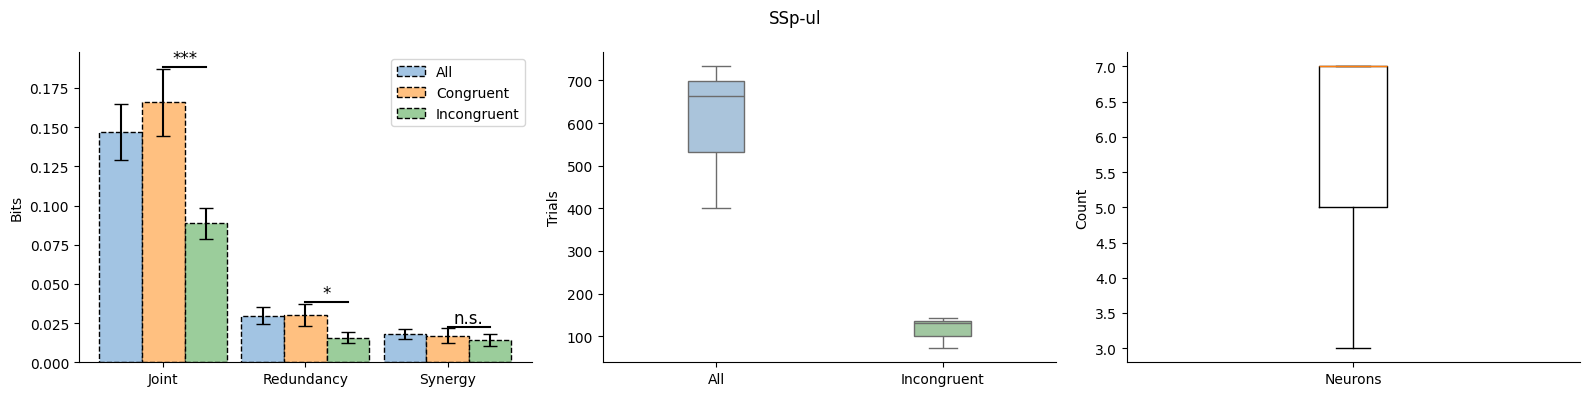

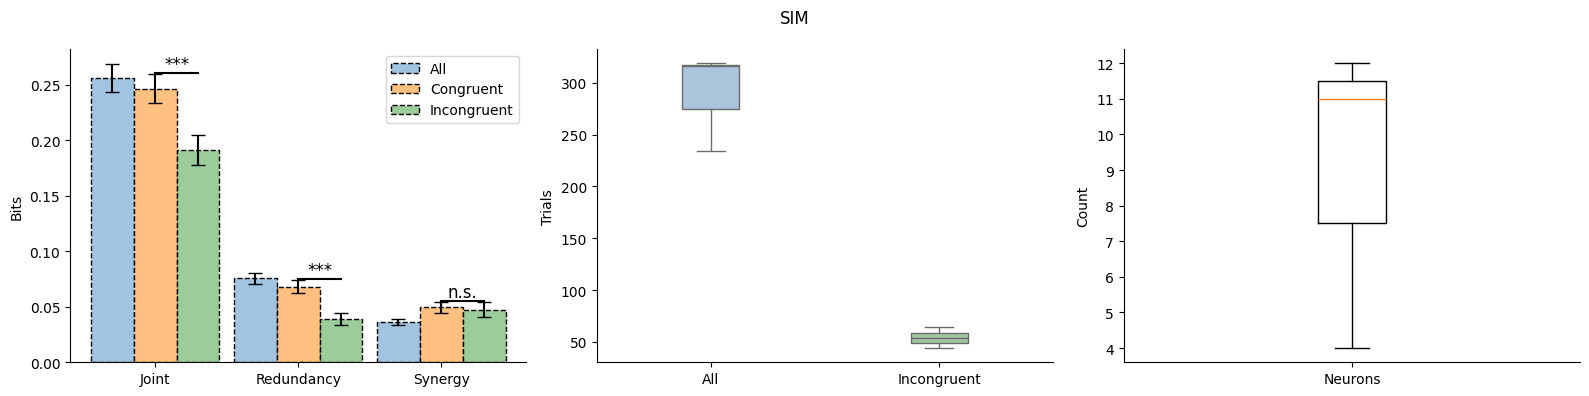

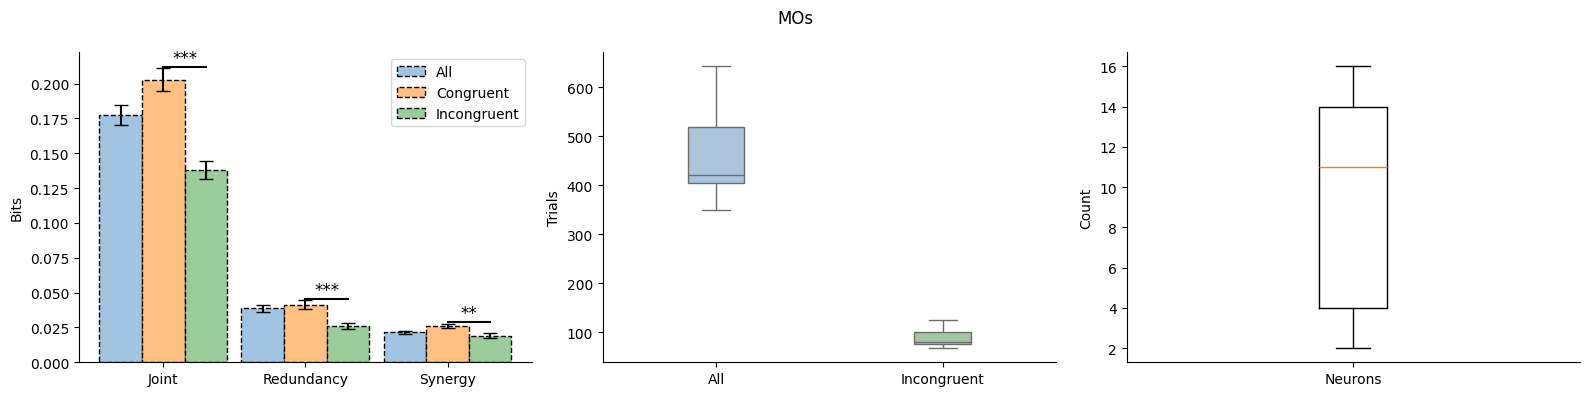

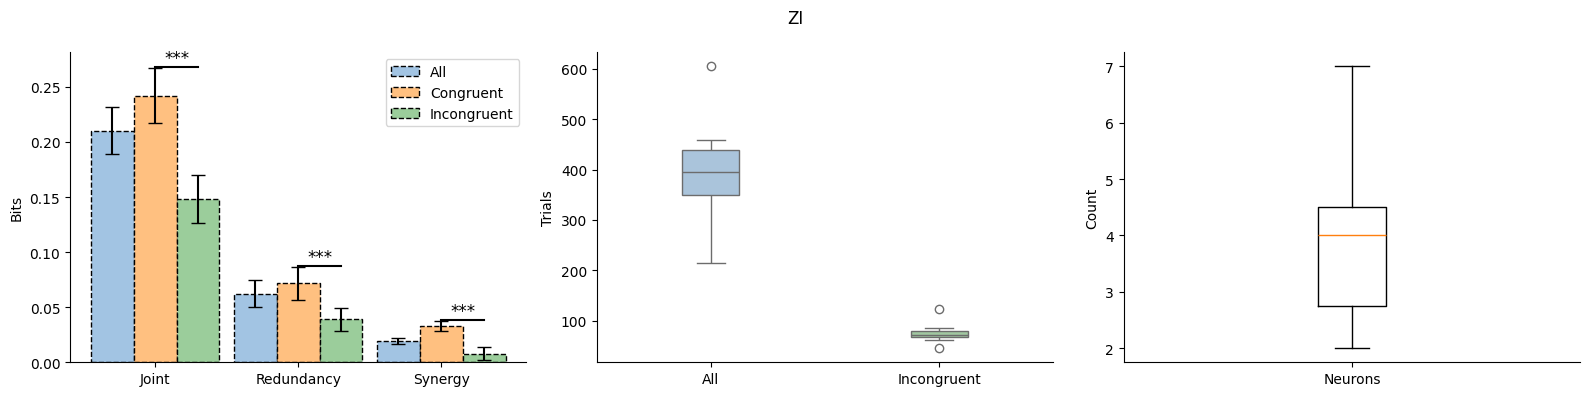

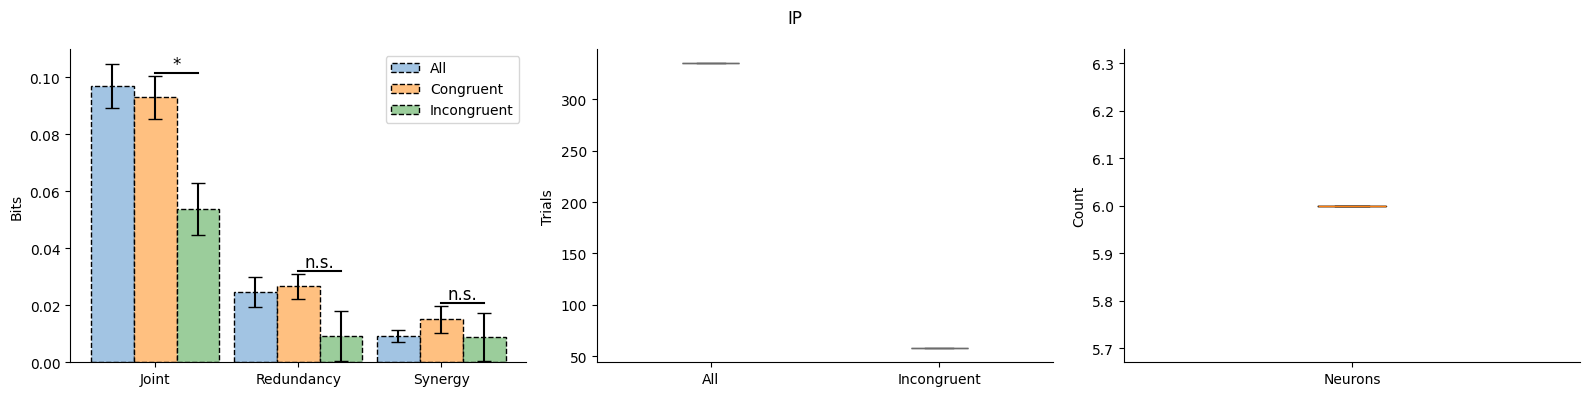

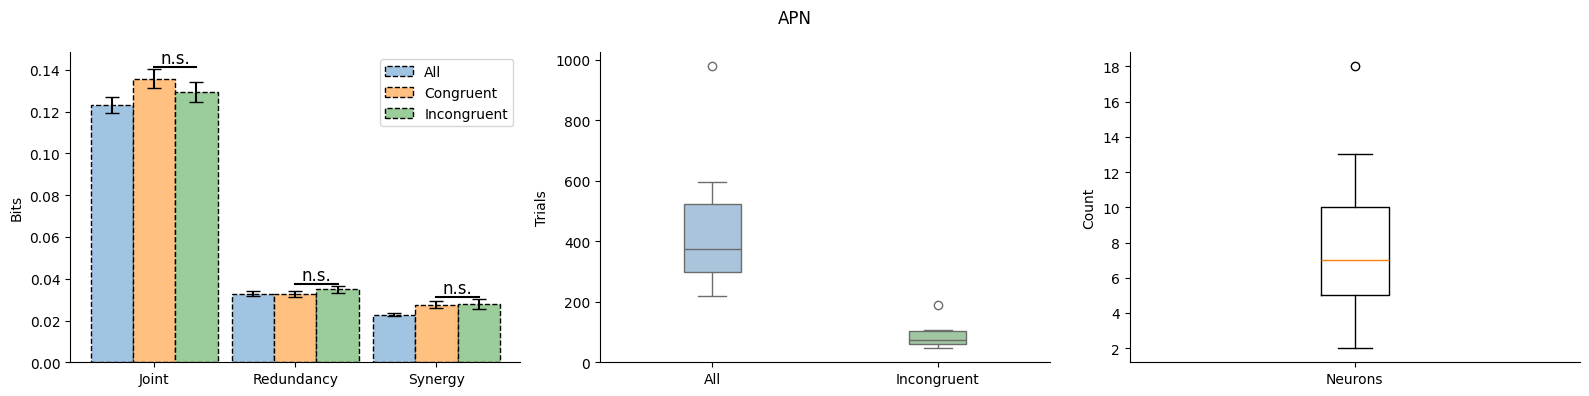

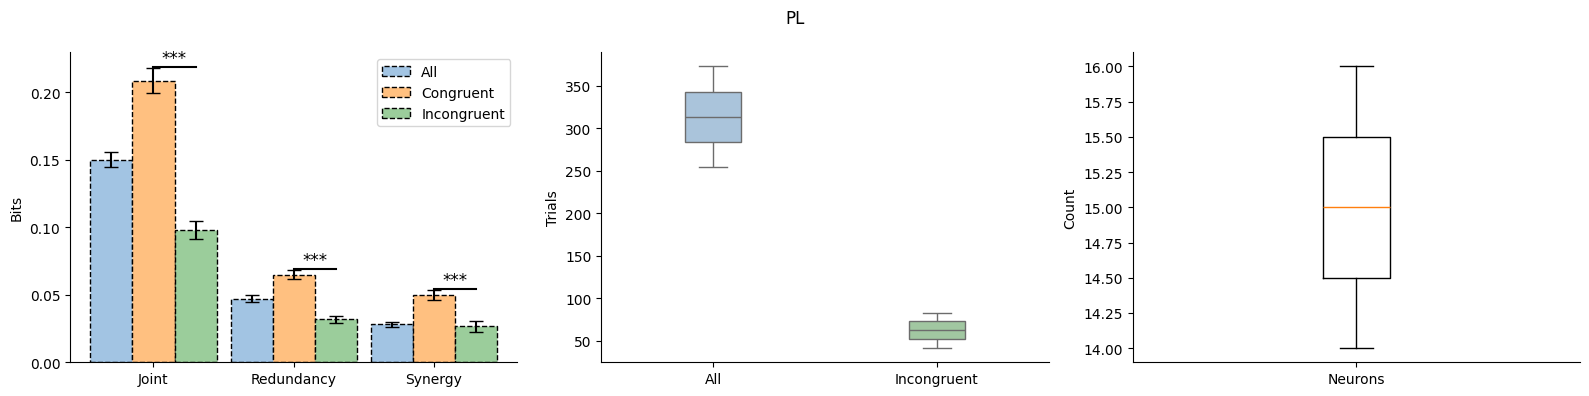

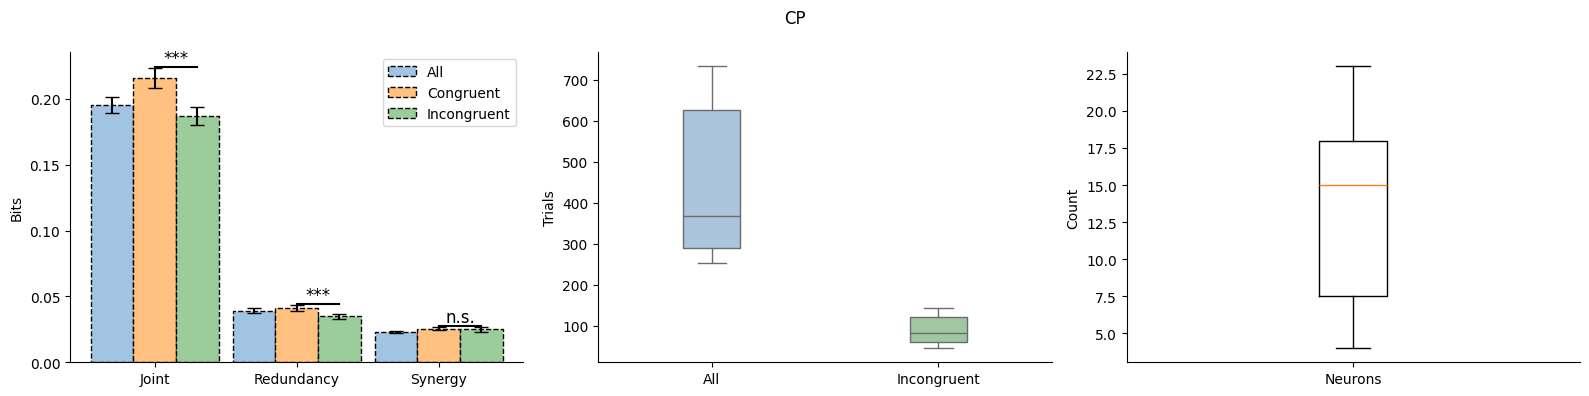

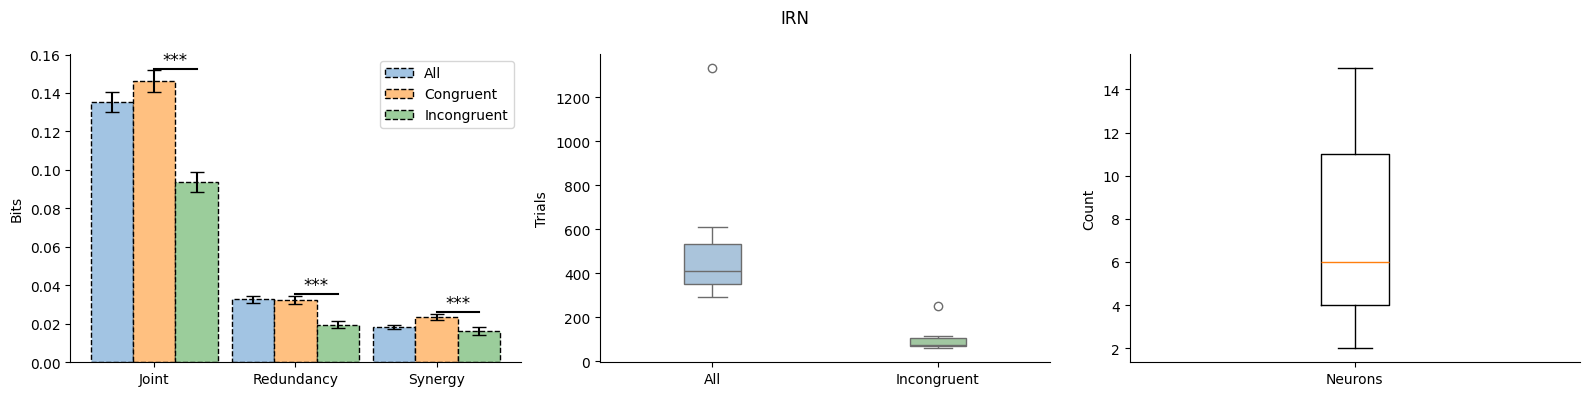

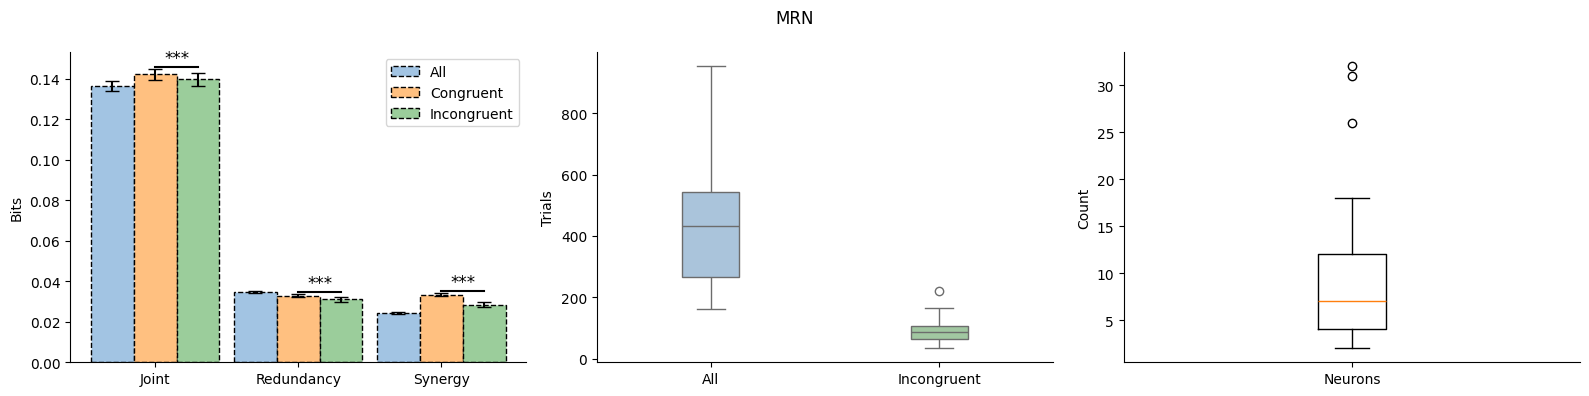

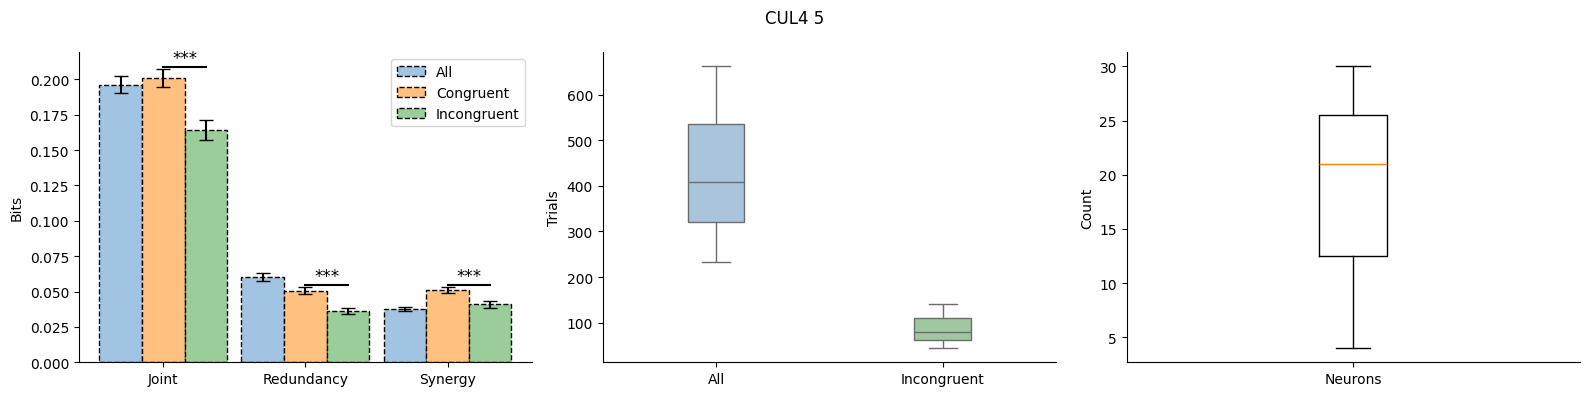

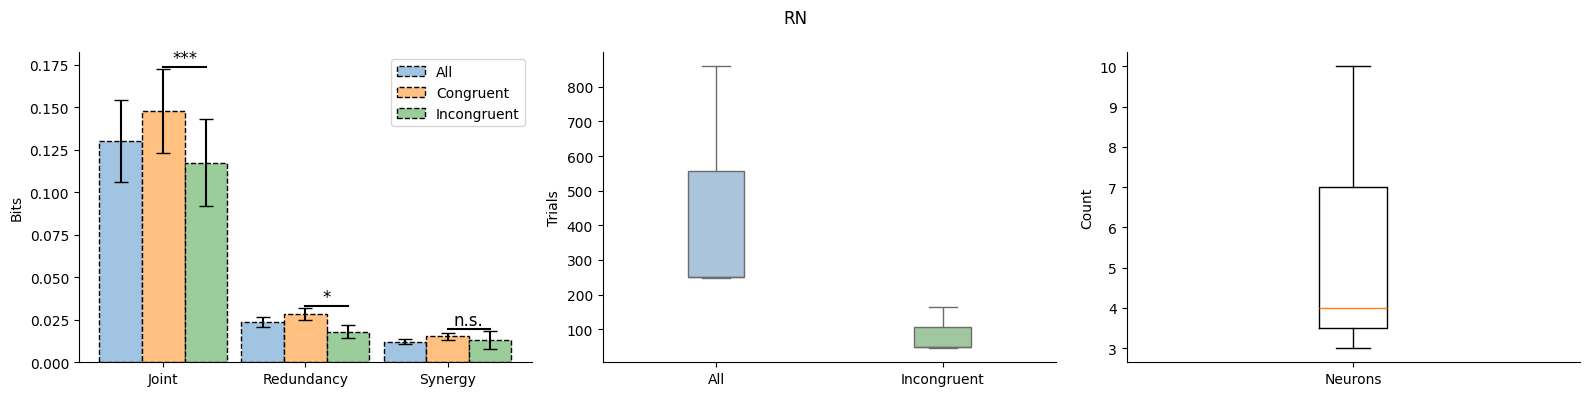

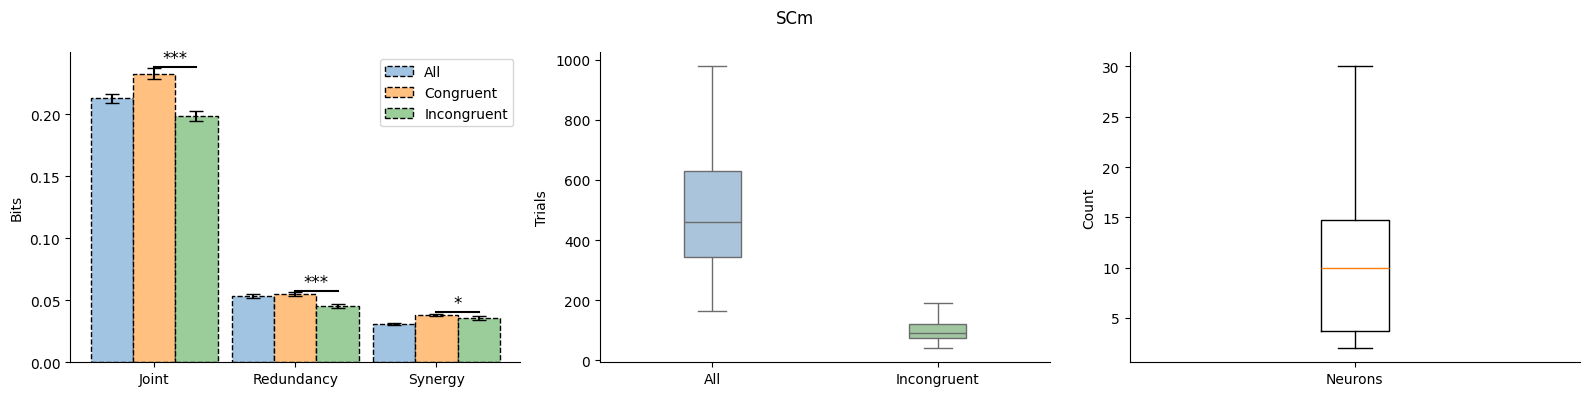

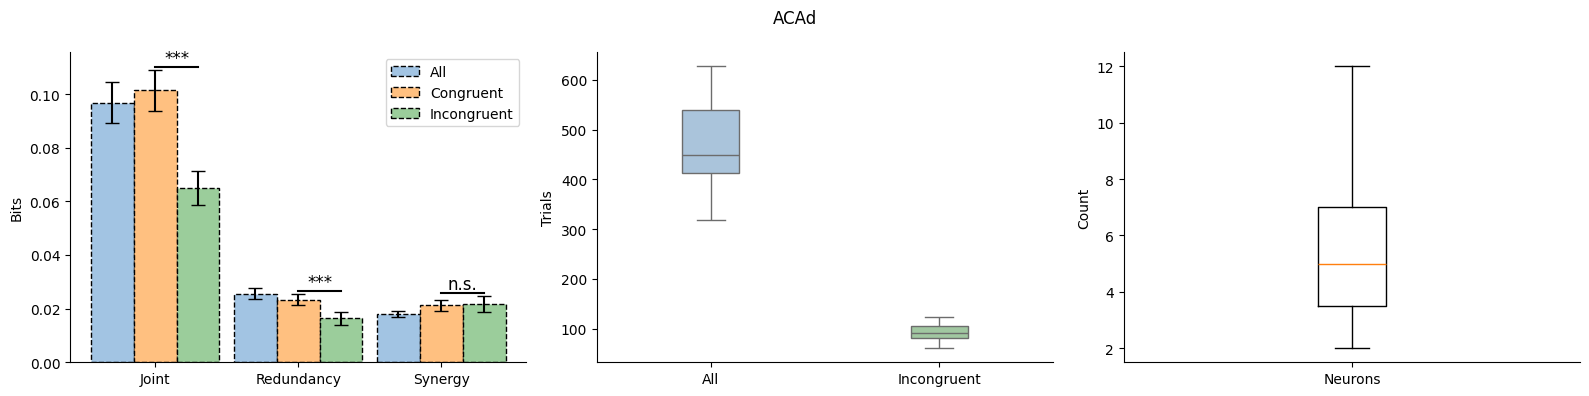

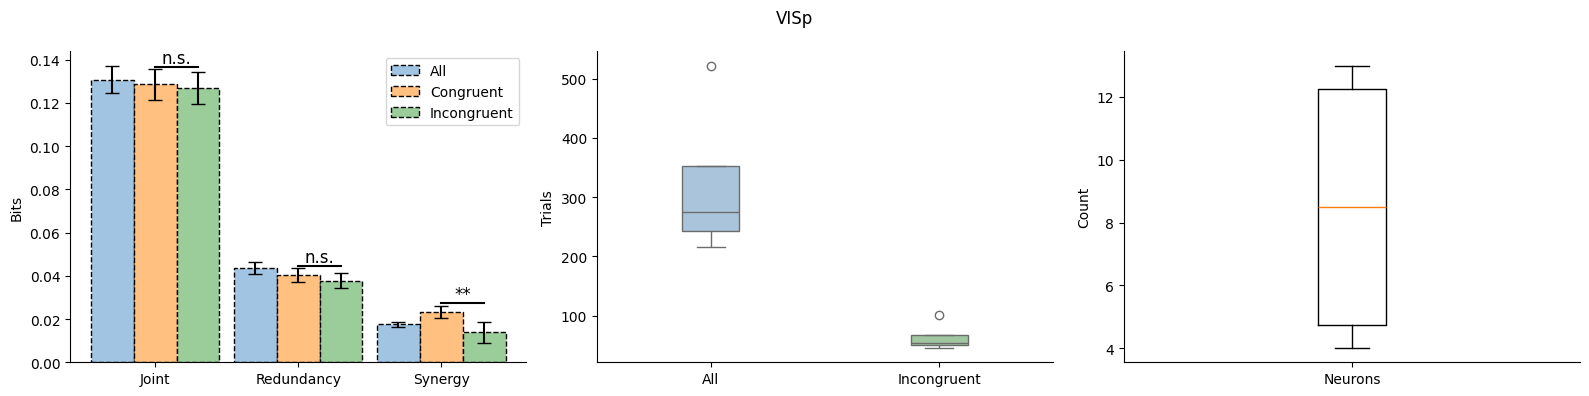

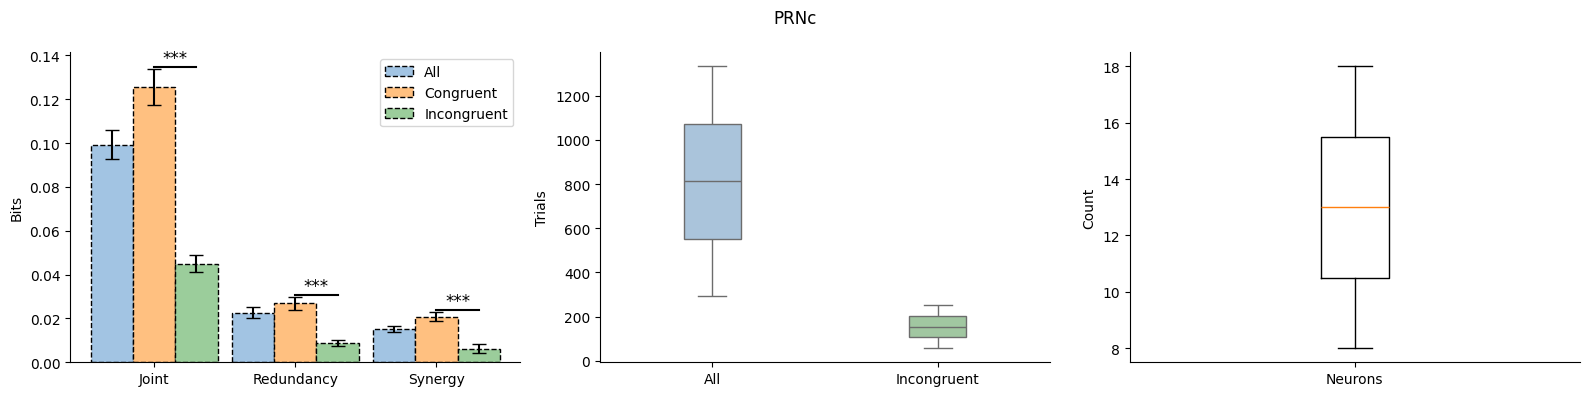

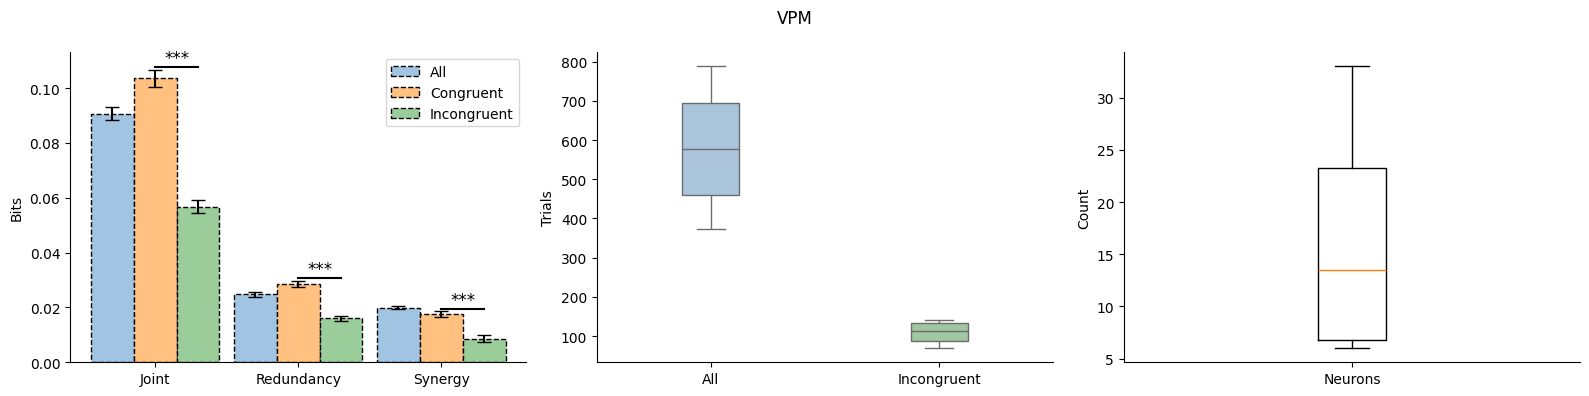

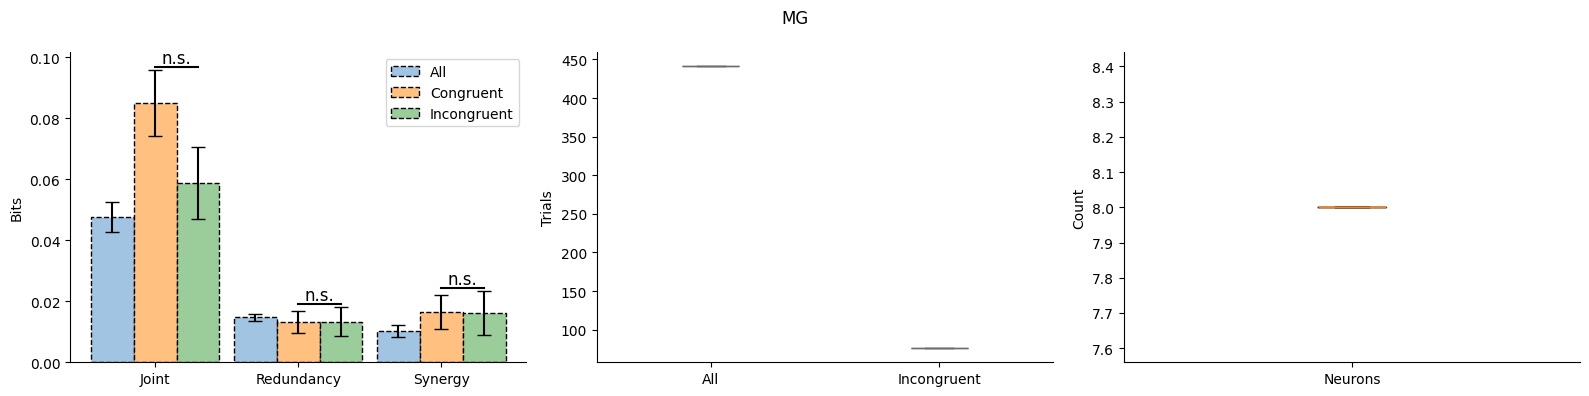

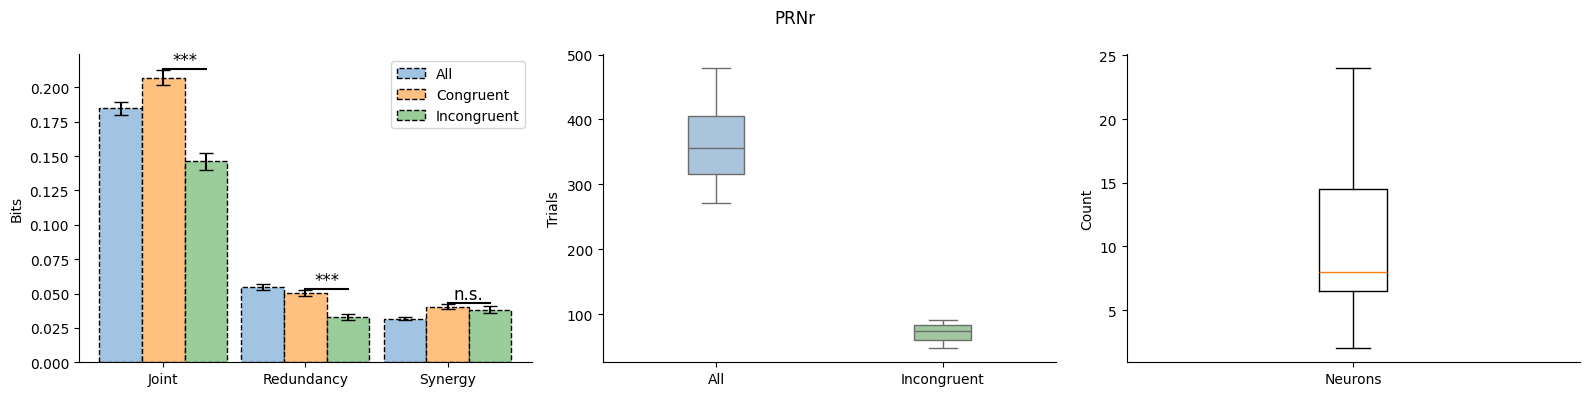

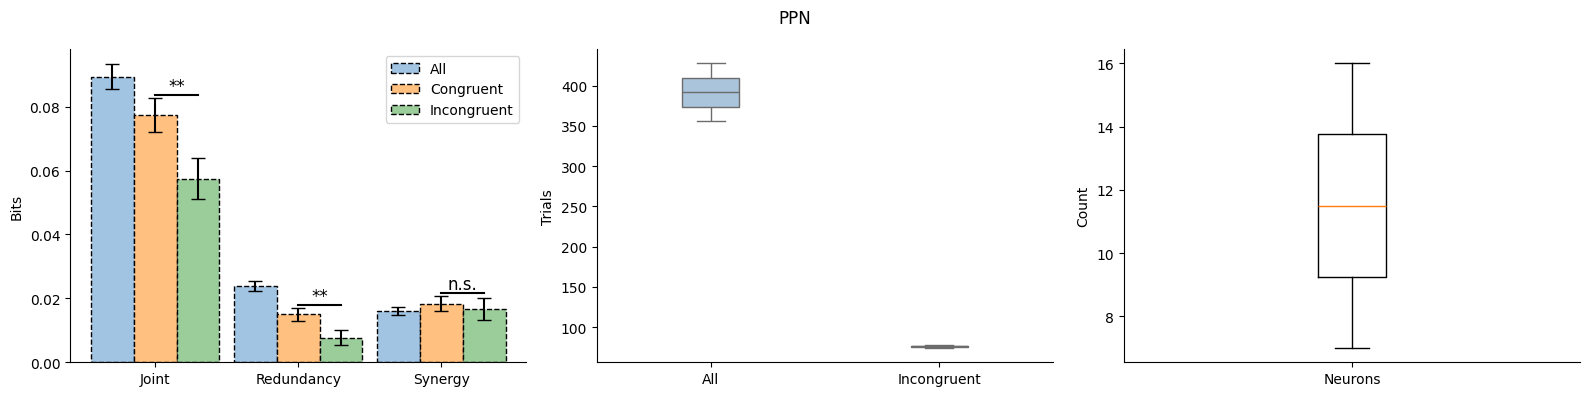

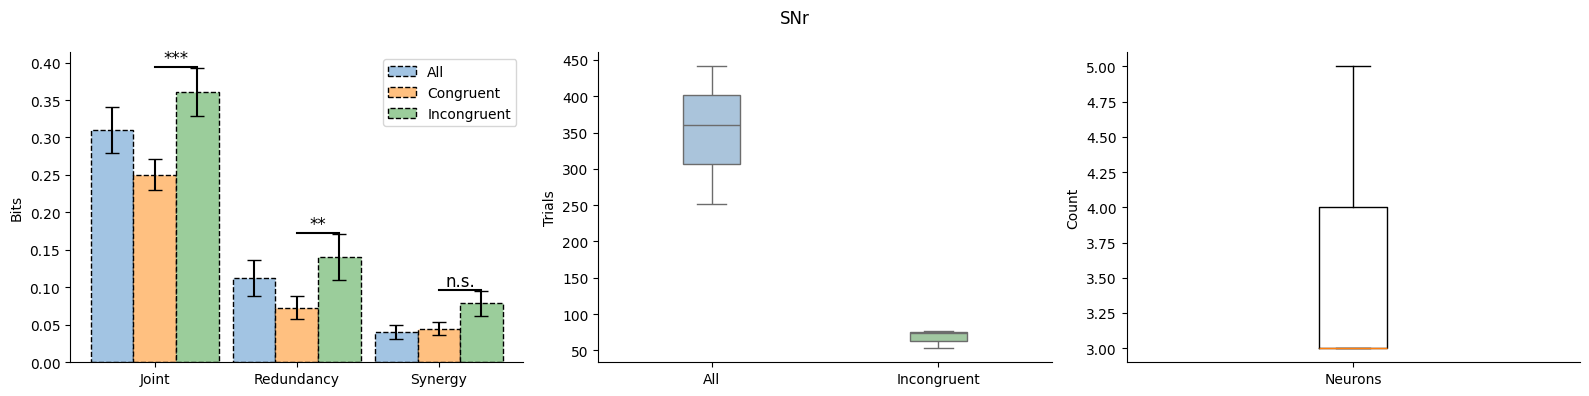

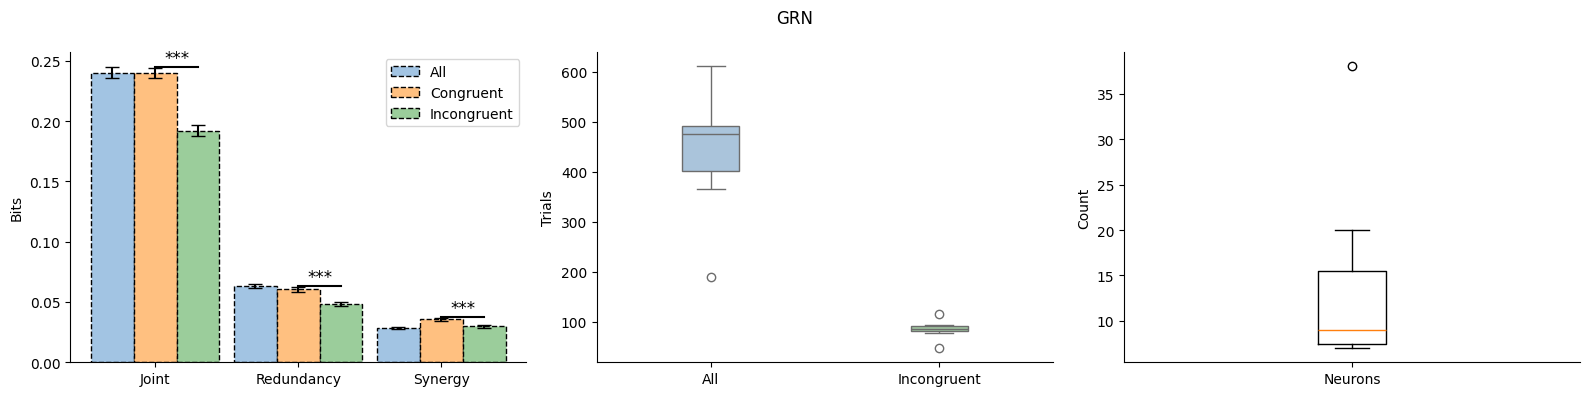

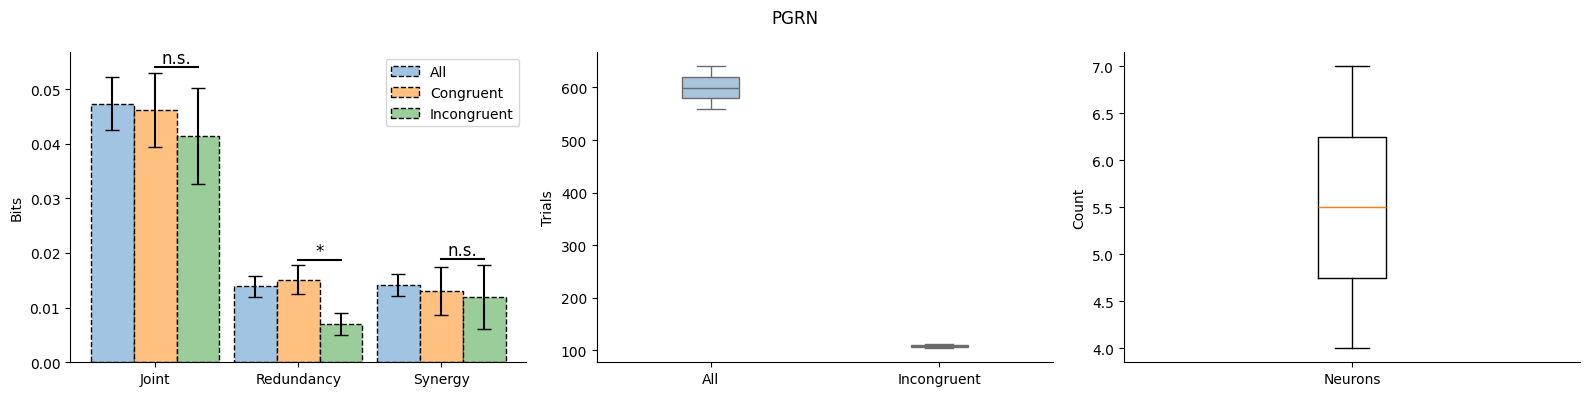

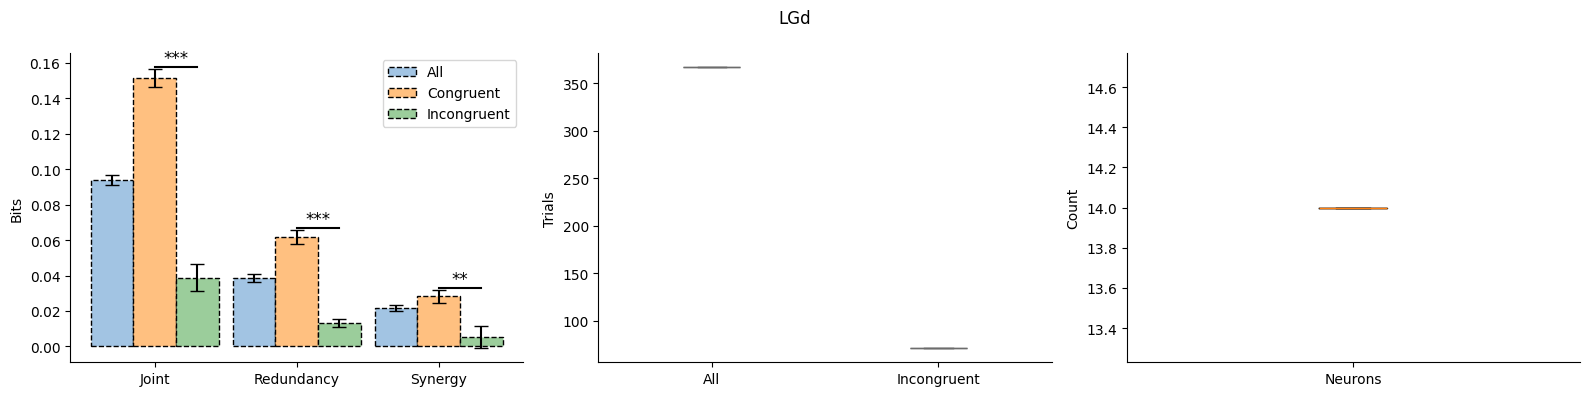

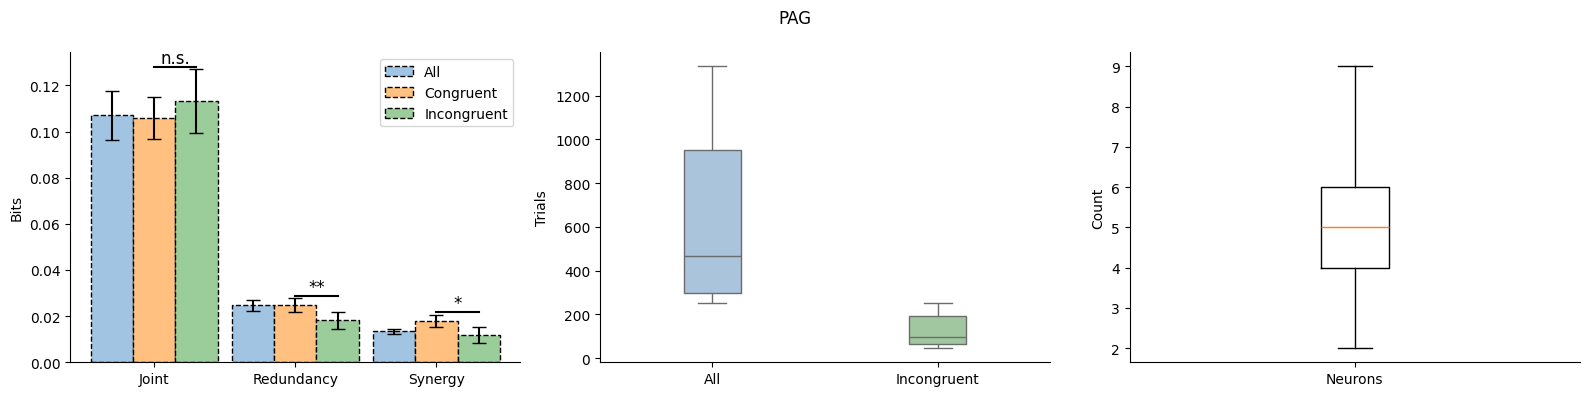

In [16]:
from tqdm import tqdm

# flatmap_differences = np.zeros((len(region_names), 4))
for idx, pickle_location in tqdm(enumerate(region_pickles)):

    with open(pickle_location, "rb") as f:
        region_data = pkl.load(f)

    region_name = region_names[idx]
    # synergy_delta, redundancy_delta, rsi_congruent, rsi_incongruent = regional_pid_results(
    #     region_data, region_name, zero_out=False, congruent_id="subsampled"
    # )
    # _ = regional_pid_results(region_data, region_name, zero_out=False, congruent_id="congruent")
    try:
        _ = regional_pid_results(
            region_data, region_name, zero_out=False, congruent_id="subsampled"
        )
        # _ = regional_pid_results(
        #     region_data, region_name, zero_out=False, congruent_id="incongruent"
        # )
    except Exception as e:
        print(f"error in {region_name}")
        print(e)
    # _ = regional_pid_results(region_data, region_name, zero_out=True, congruent_id="subsampled")
    # _ = regional_pid_results(region_data, region_name, zero_out=True, congruent_id="incongruent")
    # flatmap_differences[idx, :] = synergy_delta, redundancy_delta, rsi_congruent, rsi_incongruent

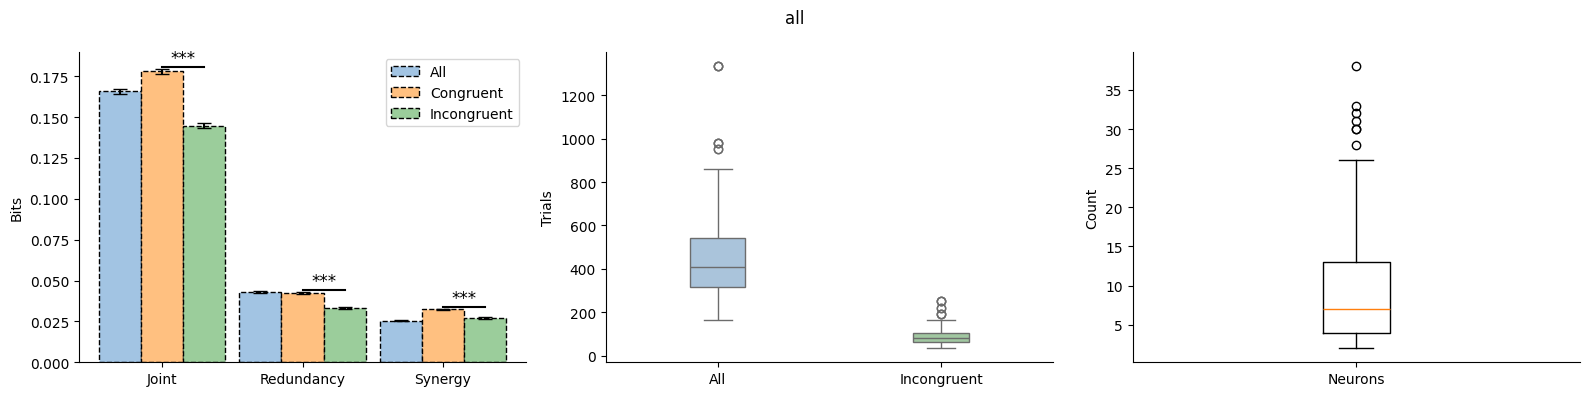

In [17]:
A = regional_pid_results(region_pickles, "all", zero_out=False, congruent_id="subsampled")

In [51]:
# _ = regional_pid_results(region_pickles, "all", zero_out=True, congruent_id="subsampled")

### swanson plots, skip

In [52]:
from ibl_info.swanson_plots import plot_vertical_swanson, plot_horizontal_swanson

In [8]:
# fig, ax = plt.subplots(figsize=(24, 24), ncols=4)
# plot_vertical_swanson(
#     region_names,
#     flatmap_differences[:, 0],
#     vmin=-0.02,
#     vmax=0.02,
#     annotate_kwargs={"annotate": True},
#     legend=False,
#     ax=ax[0],
#     cbar_shrink=0.25,
#     cbar_label="Synergy (Congruent-Incongruent)",
#     cmap="RdYlGn",
# )
# plot_vertical_swanson(
#     region_names,
#     flatmap_differences[:, 1],
#     vmin=-0.02,
#     vmax=0.02,
#     annotate_kwargs={"annotate": True},
#     legend=False,
#     ax=ax[1],
#     cbar_shrink=0.25,
#     cbar_label="Redundancy (Congruent-Incongruent)",
#     cmap="RdYlGn",
# )
# plot_vertical_swanson(
#     region_names,
#     flatmap_differences[:, 2],
#     vmin=-0.02,
#     vmax=0.02,
#     annotate_kwargs={"annotate": True},
#     legend=False,
#     ax=ax[2],
#     cbar_shrink=0.25,
#     cbar_label="Redundancy-Synergy (congruent)",
#     cmap="RdYlGn",
# )
# plot_vertical_swanson(
#     region_names,
#     flatmap_differences[:, 3],
#     vmin=-0.02,
#     vmax=0.02,
#     annotate_kwargs={"annotate": True},
#     legend=False,
#     ax=ax[3],
#     cbar_shrink=0.25,
#     cbar_label="Redundancy-Synergy (incongruent)",
#     cmap="RdYlGn",
# )

In [66]:
# spiking rate

In [67]:
from ibl_info.utils import FIRING_RATE

In [77]:
names = list(FIRING_RATE.keys())
values = np.asarray(list(FIRING_RATE.values()))

(<Axes: >, <matplotlib.colorbar.Colorbar at 0x17d04d9a0>)

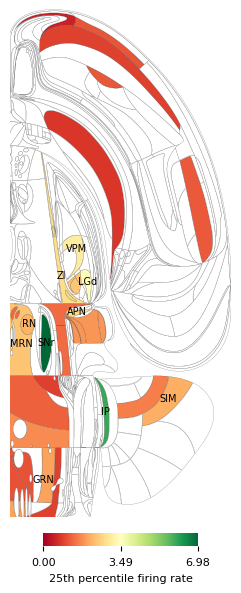

In [83]:
fig, ax = plt.subplots(figsize=(8, 8))
plot_vertical_swanson(
    names,
    values,
    vmin=0,
    vmax=np.max(values),
    annotate_kwargs={"annotate": True},
    legend=False,
    cbar_shrink=0.25,
    cbar_label="25th percentile firing rate",
    cmap="RdYlGn",
    ax=ax,
)

### Fraction of information at each level

25it [00:00, 1933.93it/s]


Text(0.5, 1.2851745561149084, 'n.s.')

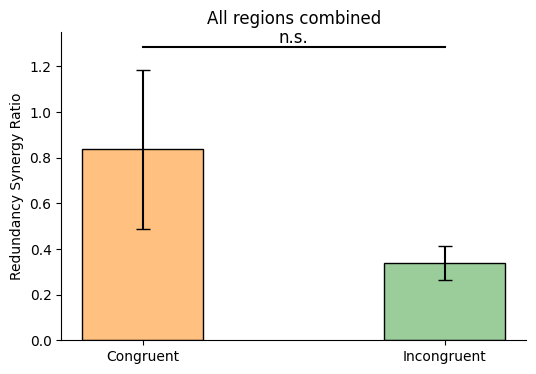

### Choice

In [11]:
region_pickles = glob("../data/generated/choice/*.pkl")
region_names = np.asarray([r.rsplit("_choice")[-2].rsplit("_")[-1] for r in region_pickles])

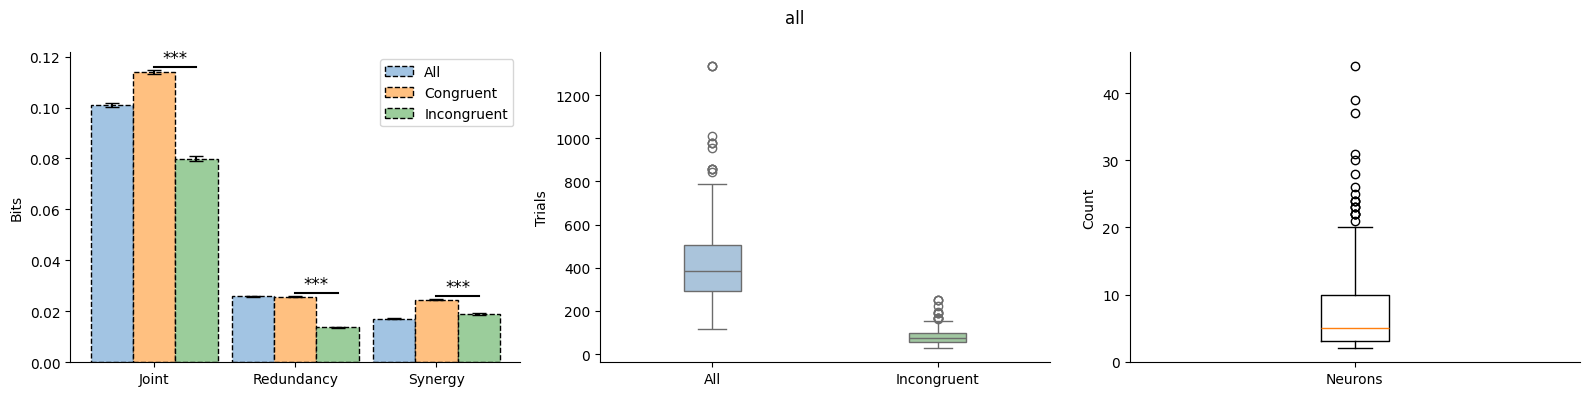

In [15]:
A = regional_pid_results(region_pickles, "all", zero_out=False, congruent_id="subsampled")

In [18]:
region_pickles = glob("../data/generated/mifiltered/3bins/*.pkl")
region_names = np.asarray([r.rsplit("_stim")[-2].rsplit("_")[-1] for r in region_pickles])

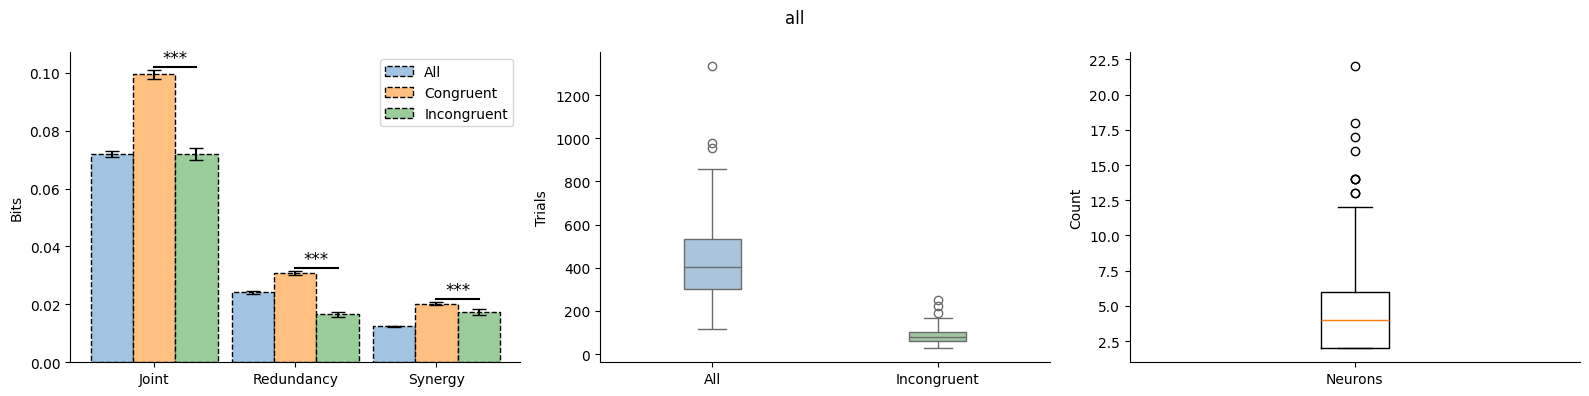

In [19]:
A = regional_pid_results(region_pickles, "all", zero_out=False, congruent_id="subsampled")